## **Project: Orange juice brand prediction using machine learning**
- **Source**: Stine, Robert A., Foster, Dean P., Waterman, Richard P. Business Analysis Using Regression (1998). Published by Springer.
- **Date**: 10/15/24
- **Goal**: Create a basic prediction model and a feature explainer

In [1]:
# Step 0. Load libraries and custom models
# Basics ---------------------------------------------------------------
import re
import pickle
import logging
# Data -----------------------------------------------------------------
import pandas as pd
import numpy as np
# Graphics -------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning -----------------------------------------------------
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.impute import (
    SimpleImputer,
    KNNImputer
)
from sklearn.preprocessing import (
    OneHotEncoder, 
    LabelEncoder,
    MinMaxScaler
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    cohen_kappa_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    DetCurveDisplay
)
from sklearn.utils import resample
# Custom modules -------------------------------------------------------
def count_nan_zeros(df: pd.DataFrame)->pd.DataFrame:
    """Count NaNs and zeros in each column of a DataFrame"""
    
    nan_zeros = {}
    for col in df.columns:
        numeric = False
        total_count = len(df[col])
        nan_count = df[col].isna().sum()
        pct_nan = round(nan_count / total_count * 100,1)
        zero_count = (df[col] == 0).sum()
        pct_zero = round(zero_count / total_count * 100,1)
        unique_count = df[col].nunique()
        if df[col].dtype.kind in 'biufc':
            numeric = True
        
        nan_zeros[col] = {'NaNs': nan_count,
                          'pct_NaNs': pct_nan, 
                          'Zeros': zero_count,
                          'pct_Zeros': pct_zero,
                          'Numeric': numeric,
                          'Unique Values': unique_count}
    
    return pd.DataFrame.from_dict(nan_zeros, orient='index')

def extreme_vars(df: pd.DataFrame, 
                 freq_cut=95/5, 
                 unique_cut=10,
                 pareto_cut=0.95)->pd.DataFrame:
    """
    Identify extreme variables like near zero variance in predictors
    nearZeroVar: diagnoses predictors that have one unique value (i.e. are
    zero variance predictors) or predictors that are have both of the following
    characteristics: they have very few unique values relative to the number of
    samples and the ratio of the frequency of the most common value to the
    frequency of the second most common value is large. \code{checkConditionalX}
    looks at the distribution of the columns of \code{x} conditioned on the
    levels of \code{y} and identifies columns of \code{x} that are sparse within
    groups of \code{y}.

    For example, an example of near zero variance predictor is one that, for
    1000 samples, has two distinct values and 999 of them are a single value.

    To be flagged, first the frequency of the most prevalent value over the
    second most frequent value (called the ``frequency ratio'') must be above
    \code{freqCut}. Secondly, the ``percent of unique values,'' the number of
    unique values divided by the total number of samples (times 100), must also
    be below \code{uniqueCut}.

    In the above example, the frequency ratio is 999 and the unique value
    percentage is 0.0001.

    Checking the conditional distribution of \code{x} may be needed for some
    models, such as naive Bayes where the conditional distributions should have
    at least one data point within a class.
    """

    extreme = {}
    for col in df.columns:
        vec_col = df[col].dropna()
        uniques = vec_col.nunique()
        percent_uniques = uniques / len(vec_col) * 100
        if uniques == 1:
            zv = True
        else:
            zv = False
        if uniques > 1:
            top_1 = round(
                vec_col.value_counts(normalize=True).values[0] * 100,1
            )
            top_2 = round(
                vec_col.value_counts(normalize=True).values[1] * 100,1
            )
            freq_ratio = top_1 / top_2
        else:
            freq_ratio = 0
        if (freq_ratio > freq_cut and percent_uniques <= unique_cut) or zv:
            nzv = True
        else:
            nzv = False

        if vec_col.dtype.kind in 'biufc':
            iqr = vec_col.quantile(0.75) - vec_col.quantile(0.25)
            lim = np.abs((vec_col-vec_col.median())/iqr) < 2.22
            outliers = True if lim.sum() > 0 else False
        else:
            outliers = '-'

        if vec_col.dtype.kind in 'biufc':
            pos_vals = (vec_col > 0).sum()
            neg_vals = (vec_col < 0).sum()
        else:
            pos_vals = neg_vals = '-'

        if vec_col.dtype == 'category':
            acum = vec_col.value_counts(normalize=True).cumsum()
            pareto_cats = len(acum[acum<pareto_cut])
        else:
            pareto_cats = '-'
        
        extreme[col] = {'zero_var': zv,
                        'near_zero_var': nzv,
                        'outliers': outliers,
                        'pos_vals': pos_vals,
                        'neg_vals': neg_vals,
                        'pareto_cats': pareto_cats}
    return pd.DataFrame.from_dict(extreme, orient='index')
    
# Logging --------------------------------------------------------------
logger = logging.getLogger()
logger.setLevel(logging.INFO)

### **1. Data loading**
**Objective**: Obtain the data from source and get a first glimpse of their properties and presentation

In [2]:
# Step 1. Load data and get a glimpse
# 1.1 Load file, get info
url = '../data/raw/orange_juice.csv'
df_raw = pd.read_csv(url)
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1070 non-null   int64  
 1   Purchase        1070 non-null   object 
 2   WeekofPurchase  1070 non-null   int64  
 3   StoreID         1069 non-null   float64
 4   PriceCH         1069 non-null   float64
 5   PriceMM         1066 non-null   float64
 6   DiscCH          1068 non-null   float64
 7   DiscMM          1066 non-null   float64
 8   SpecialCH       1068 non-null   float64
 9   SpecialMM       1065 non-null   float64
 10  LoyalCH         1065 non-null   float64
 11  SalePriceMM     1065 non-null   float64
 12  SalePriceCH     1069 non-null   float64
 13  PriceDiff       1069 non-null   float64
 14  Store7          1070 non-null   object 
 15  PctDiscMM       1065 non-null   float64
 16  PctDiscCH       1068 non-null   float64
 17  ListPriceDiff   1070 non-null   f

In [3]:
# 1.2 Get a sample
df_raw.sample(12, random_state=2024)

,Unnamed: 0,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
963,963,MM,229,1.0,1.69,1.69,0.00,0.00,0.0,0.0,0.680000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1.0
219,219,CH,272,7.0,1.86,2.13,0.00,0.00,0.0,0.0,0.989732,2.13,1.86,0.27,Yes,0.000000,0.000000,0.27,0.0
770,770,MM,229,2.0,1.69,1.69,0.00,0.00,0.0,0.0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,2.0
556,556,MM,275,1.0,1.96,2.13,0.00,0.74,0.0,1.0,0.477037,1.39,1.96,-0.57,No,0.347418,0.000000,0.17,1.0
793,793,MM,257,1.0,1.76,2.18,0.00,0.00,0.0,0.0,0.083886,2.18,1.76,0.42,No,0.000000,0.000000,0.42,1.0
952,952,MM,267,2.0,1.86,2.18,0.00,0.40,0.0,1.0,0.003817,1.78,1.86,-0.08,No,0.183486,0.000000,0.32,2.0
1,1,CH,239,1.0,1.75,1.99,0.00,0.30,0.0,1.0,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1.0
833,833,MM,241,3.0,1.79,2.23,0.00,0.00,0.0,0.0,0.204800,2.23,1.79,0.44,No,0.000000,0.000000,0.44,3.0
824,824,CH,232,4.0,1.79,2.09,0.00,0.00,0.0,0.0,0.867041,2.09,1.79,0.30,No,0.000000,0.000000,0.30,4.0
138,138,CH,278,2.0,1.99,2.18,0.00,0.00,0.0,0.0,0.988272,2.18,1.99,0.19,No,0.000000,0.000000,0.19,2.0


### **2. Data preprocessing**
**Objectives**: Perform the data cleaning, data transformation and data reduction steps to avoid data mistmatching, noisy data or data not wrangled

In [4]:
# Step 2. Prepara the dataset for analysis
# 2.1 Make transformations using a pipeline
df_baking = (
    df_raw
    .copy()
    .set_axis(
        df_raw.columns.str.replace(' ','_')
        .str.replace(r'\W','',regex=True)
        .str.lower()
        .str.slice(0,40), axis=1
    )
    .drop(
        ['weekofpurchase','pctdiscch','pctdiscmm',
         'pricediff','listpricediff','store'], axis=1
    )
    .rename(columns={'purchase':'target'})
    .astype({'target':'category',
             'storeid':'category',
             'store7':'category',
             'specialch':'category',
             'specialmm':'category'})
    .iloc[:,1:]
)
#.iloc[:, [-1] + [x for x in range(df_raw.shape[1]) if x!=4]]
df_baking.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   target       1070 non-null   category
 1   storeid      1069 non-null   category
 2   pricech      1069 non-null   float64 
 3   pricemm      1066 non-null   float64 
 4   discch       1068 non-null   float64 
 5   discmm       1066 non-null   float64 
 6   specialch    1068 non-null   category
 7   specialmm    1065 non-null   category
 8   loyalch      1065 non-null   float64 
 9   salepricemm  1065 non-null   float64 
 10  salepricech  1069 non-null   float64 
 11  store7       1070 non-null   category
dtypes: category(5), float64(7)
memory usage: 64.6 KB


In [5]:
# 2.2 Create the final dataset
df = df_baking.copy()
df.sample(5, random_state=2024)

,target,storeid,pricech,pricemm,discch,discmm,specialch,specialmm,loyalch,salepricemm,salepricech,store7
963,MM,1.0,1.69,1.69,0.0,0.00,0.0,0.0,0.680000,1.69,1.69,No
219,CH,7.0,1.86,2.13,0.0,0.00,0.0,0.0,0.989732,2.13,1.86,Yes
770,MM,2.0,1.69,1.69,0.0,0.00,0.0,0.0,0.400000,1.69,1.69,No
556,MM,1.0,1.96,2.13,0.0,0.74,0.0,1.0,0.477037,1.39,1.96,No
793,MM,1.0,1.76,2.18,0.0,0.00,0.0,0.0,0.083886,2.18,1.76,No


### **3. Exploratory Data Analysis**
**Objective**: Summarize the main characteristics of the dataset using descriptive statistics and data visualization methods

In [6]:
# Step 3. EDA
# 3.1 Create train and test splits
df_train, df_test = train_test_split(
    df, stratify=df['target'], 
    test_size=0.15, random_state=2024
)
df_train, df_val = train_test_split(
    df_train, stratify=df_train['target'], 
    test_size=0.15, random_state=2024
)
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)
df_train.shape, df_val.shape, df_test.shape

((772, 12), (137, 12), (161, 12))

In [7]:
# 3.2 Get numerical and category summaries
display(df_train.describe(include='number').T)
display(df_train.describe(include='category').T)

,count,mean,std,min,25%,50%,75%,max
pricech,772.0,1.869560,0.102478,1.690000,1.7900,1.86000,1.990000,2.090000
pricemm,771.0,2.085214,0.138757,1.690000,1.9900,2.13000,2.180000,2.290000
discch,770.0,0.051234,0.116926,0.000000,0.0000,0.00000,0.000000,0.500000
discmm,770.0,0.126390,0.214792,0.000000,0.0000,0.00000,0.240000,0.800000
loyalch,770.0,0.566009,0.310909,0.000011,0.3299,0.59712,0.858173,0.999947
salepricemm,767.0,1.958722,0.255136,1.190000,1.6900,2.09000,2.180000,2.290000
salepricech,771.0,1.818405,0.144015,1.390000,1.7500,1.86000,1.890000,2.090000


,count,unique,top,freq
target,772,2,CH,471
storeid,772.0,5.0,7.0,245.0
specialch,770.0,2.0,0.0,660.0
specialmm,769.0,2.0,0.0,637.0
store7,772,2,No,527


In [8]:
# 3.3 Get the count of zeros and nans on the train dataset
count_nan_zeros(df_train)

,NaNs,pct_NaNs,Zeros,pct_Zeros,Numeric,Unique Values
target,0,0.0,0,0.0,False,2
storeid,0,0.0,0,0.0,False,5
pricech,0,0.0,0,0.0,True,10
pricemm,1,0.1,0,0.0,True,8
discch,2,0.3,605,78.4,True,12
discmm,2,0.3,528,68.4,True,12
specialch,2,0.3,660,85.5,False,2
specialmm,3,0.4,637,82.5,False,2
loyalch,2,0.3,0,0.0,True,424
salepricemm,5,0.6,0,0.0,True,18


In [9]:
extreme_vars(df_train)

,zero_var,near_zero_var,outliers,pos_vals,neg_vals,pareto_cats
target,False,False,-,-,-,1
storeid,False,False,-,-,-,4
pricech,False,False,True,772,0,-
pricemm,False,False,True,771,0,-
discch,False,False,False,165,0,-
discmm,False,False,True,242,0,-
specialch,False,False,-,-,-,1
specialmm,False,False,-,-,-,1
loyalch,False,False,True,770,0,-
salepricemm,False,False,True,767,0,-


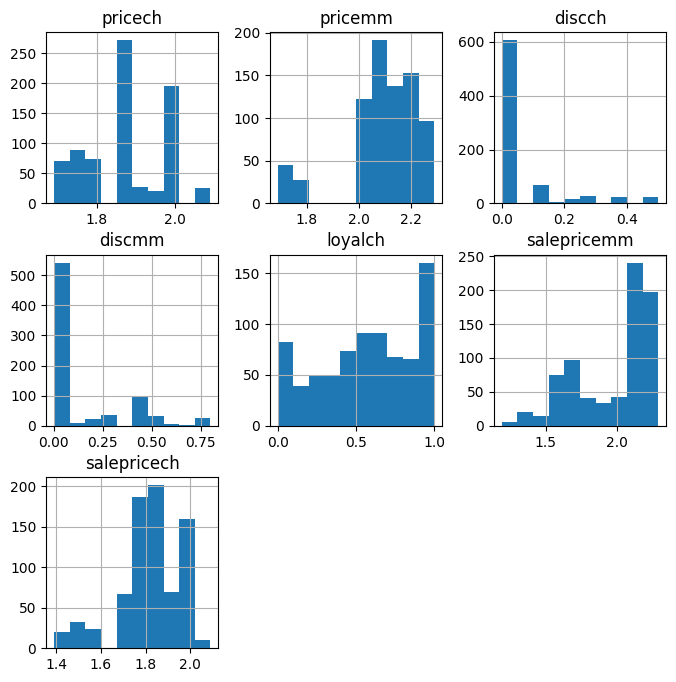

In [10]:
# 3.3 Perform univariate analysis - number
df_train.hist(figsize=(8,8))
plt.show()

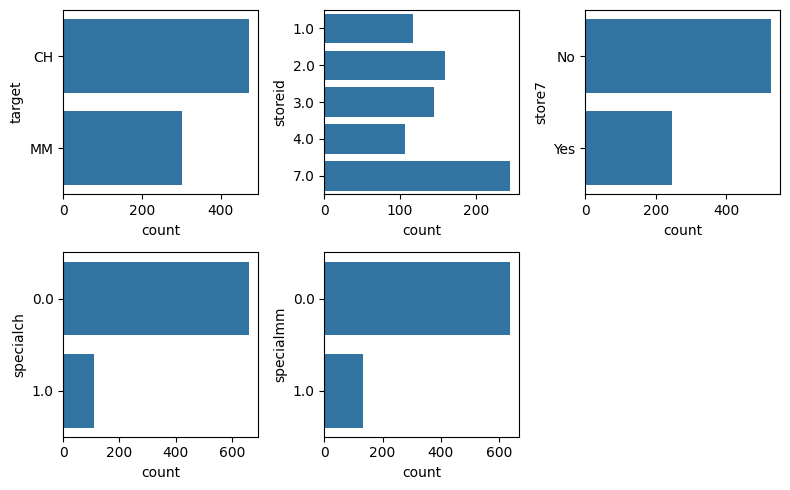

In [11]:
# 3.4 Perform univariate analysis - category
fig, ax = plt.subplots(2,3, figsize=(8,5))
sns.countplot(data=df_train, y='target', ax=ax[0,0])
sns.countplot(data=df_train, y='storeid', ax=ax[0,1])
sns.countplot(data=df_train, y='store7', ax=ax[0,2])
sns.countplot(data=df_train, y='specialch', ax=ax[1,0])
sns.countplot(data=df_train, y='specialmm', ax=ax[1,1])
fig.delaxes(ax[1,2])
fig.tight_layout()
plt.show()

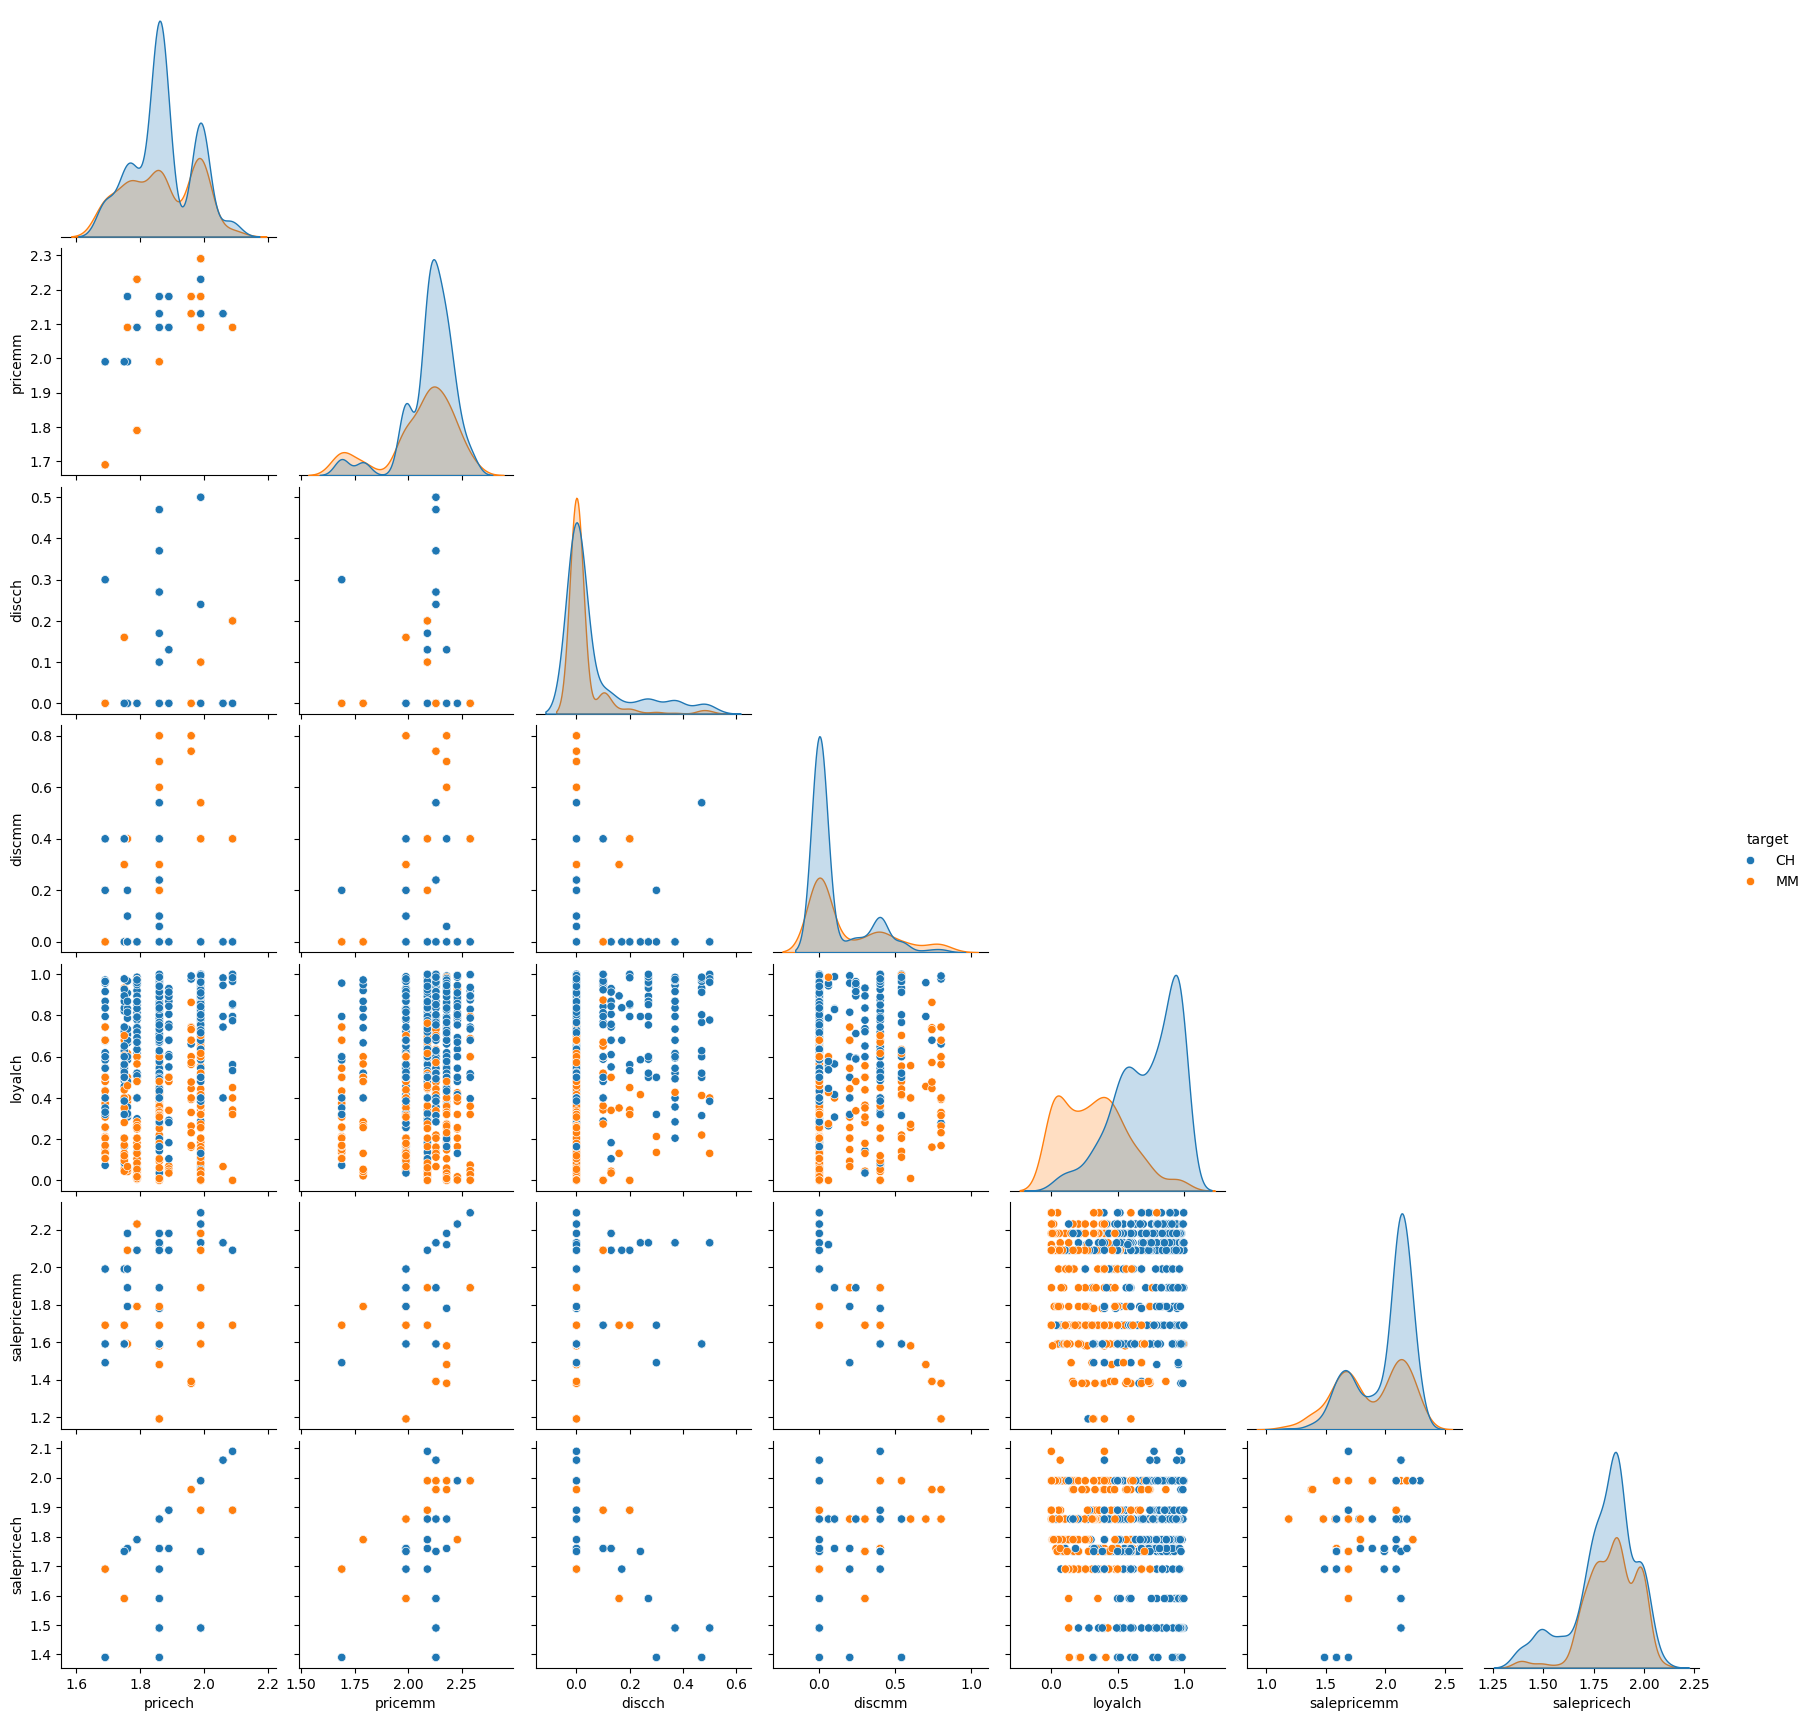

In [12]:
# 3.5 Perform bivariate analysis - Numerical vs target
sns.pairplot(data=df_train, hue='target', corner=True)
plt.show()

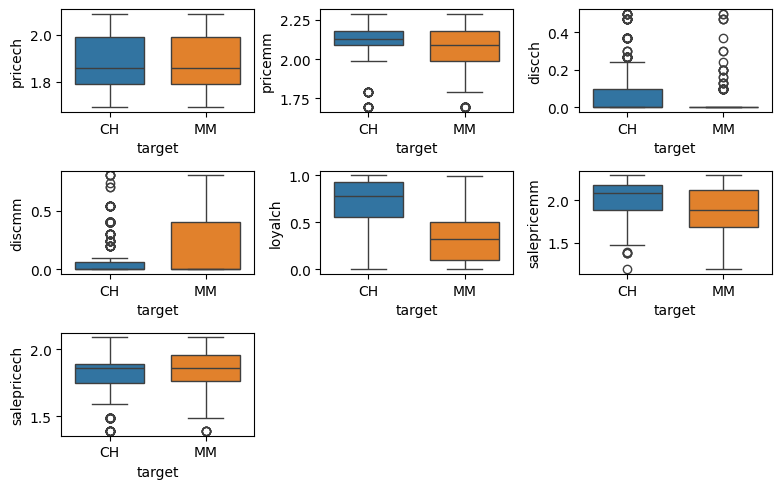

In [13]:
# 3.5.1 View boxplots vs target
fig, ax = plt.subplots(3,3, figsize=(8,5))
axs = ax.flatten()
numcols = df_train.select_dtypes('number').columns
for i in range(len(numcols)):
    sns.boxplot(data=df_train, y=numcols[i], x='target', 
                hue='target', gap=.1, ax=axs[i], legend=None)
fig.delaxes(axs[7])
fig.delaxes(axs[8])
fig.tight_layout()
plt.show()

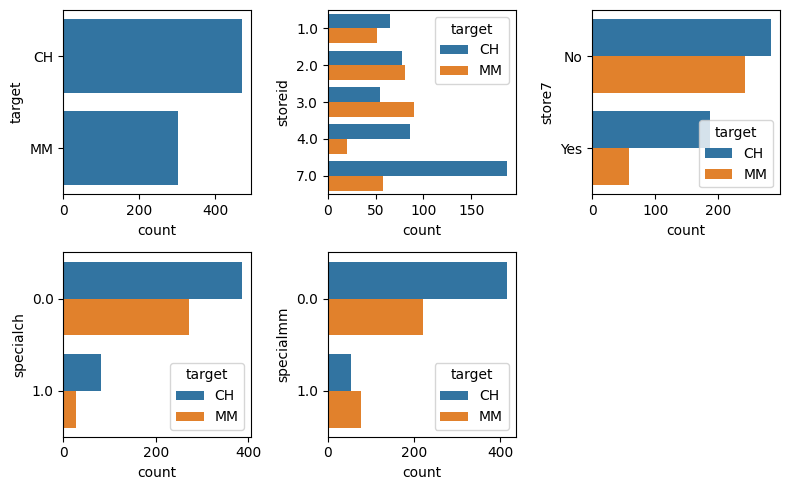

In [14]:
# 3.6 Perform bivariate analysis - Categorical vs target
fig, ax = plt.subplots(2,3, figsize=(8,5))
sns.countplot(data=df_train, y='target', ax=ax[0,0])
sns.countplot(data=df_train, y='storeid', hue='target', ax=ax[0,1])
sns.countplot(data=df_train, y='store7', hue='target', ax=ax[0,2])
sns.countplot(data=df_train, y='specialch', hue='target', ax=ax[1,0])
sns.countplot(data=df_train, y='specialmm', hue='target', ax=ax[1,1])
fig.delaxes(ax[1,2])
fig.tight_layout()
plt.show()

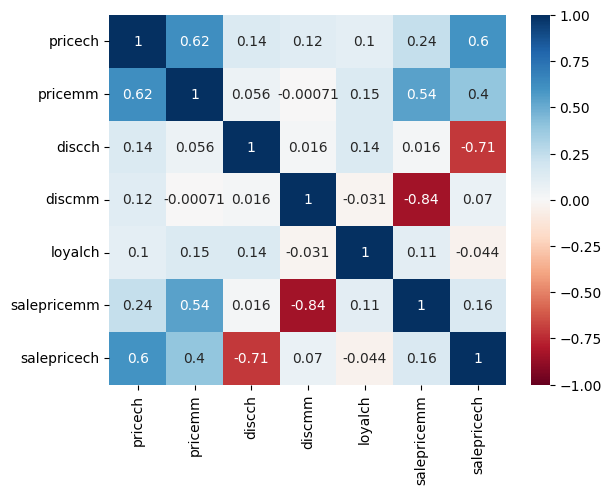

In [15]:
# 3.7 Perform correlation analysis
sns.heatmap(
    df_train.select_dtypes('number').corr(), 
    vmin=-1, vmax=1, annot=True, cmap='RdBu')
plt.show()

### **4. Machine learning**
**Objective**: Create a model that learns from data to make predictions and generalize to unseen data, and thus perform tasks without explicit instructions

In [16]:
# Step 4. Create a machine learning model
# 4.1 Split features and reponse
X_train = df_train.drop(['target'], axis=1)
y_train = df_train['target']
X_val = df_val.drop(['target'], axis=1)
y_val = df_val['target']
X_test = df_test.drop(['target'], axis=1)
y_test = df_test['target']

In [17]:
# 4.2 Encode the response 
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

In [18]:
# 4.3 Create a pipeline for data
cat_cols = X_train.select_dtypes('category').columns
num_cols = X_train.select_dtypes('number').columns

cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('minmax', MinMaxScaler())
])

processor = ColumnTransformer(transformers=[
    ('cat', cat_proc, cat_cols),
    ('num', num_proc, num_cols)
])

In [19]:
# 4.4 Create pipelines for model training
clf_rf = Pipeline([
    ('proc',processor),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=2024))
])

clf_hgb = Pipeline([
    ('proc',processor),
    ('hgb', HistGradientBoostingClassifier(class_weight='balanced', random_state=2024))
])

clf_svc = Pipeline([
    ('proc', processor),
    ('svc', SVC(class_weight='balanced', random_state=2024))
])

In [20]:
# 4.5 Create grid search params
rf_param_grid={
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 3, 5, 7, 9, 11],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4]
}

hgb_param_grid = {
    'hgb__learning_rate': [0.01, 0.1, 0.5],
    'hgb__max_iter': [100, 200, 300],
    'hgb__max_depth': [None, 3, 5, 7, 9, 11],
    'hgb__min_samples_leaf': [1, 2, 4]
}

svc_param_grid = {
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'svc__kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}

In [21]:
# 4.6 Create models dictionary
models = {
    'random_forest':{
        'model': clf_rf,
        'params': rf_param_grid
    },
    'histgradient_boosting':{
        'model': clf_hgb,
        'params': hgb_param_grid
    },
    'support_vector':{
        'model': clf_svc,
        'params': svc_param_grid
    }
}

In [22]:
# 4.7 Train the model 
results = {}
for model in models:
    gscv = GridSearchCV(
        estimator=models[model]['model'],
        param_grid=models[model]['params'],
        cv=6,
        scoring='f1_weighted',
        n_jobs=3
    )
    gscv.fit(X_train, y_train_enc)
    y_hat_val = gscv.predict(X_val)
    print("-----------------------------------------------------")
    print(f"Model: {model.replace('_',' ')}")
    print(f"Accuracy: {accuracy_score(y_val_enc, y_hat_val):.3f}")
    print(f"F1 Score: {f1_score(y_val_enc, y_hat_val, average='weighted'):.3f}")
    print(f"Kappa: {cohen_kappa_score(y_val_enc, y_hat_val):.3f}")
    print(f"Precision: {precision_score(y_val_enc, y_hat_val, average='weighted'):.3f}")
    print(f"Recall: {recall_score(y_val_enc, y_hat_val, average='weighted'):.3f}")
    results[model] = gscv
    params = {re.sub('.+__','',k):v for k,v in gscv.best_params_.items()}
    models[model]['best_params'] = params
    gscv.best_params_
    

-----------------------------------------------------
Model: random forest
Accuracy: 0.788
F1 Score: 0.790
Kappa: 0.561
Precision: 0.793
Recall: 0.788
-----------------------------------------------------
Model: histgradient boosting
Accuracy: 0.788
F1 Score: 0.790
Kappa: 0.564
Precision: 0.796
Recall: 0.788
-----------------------------------------------------
Model: support vector
Accuracy: 0.810
F1 Score: 0.811
Kappa: 0.605
Precision: 0.814
Recall: 0.810


In [ ]:
# 4.8 Calculate estimates for model using resampling
n_iterations = 100
bootstrap_model = []
auc_scores = []
kappa_scores = []
f1_scores = []
accuracy_scores = []
bootstrap_model_ci = {} 
model_algorithms = (RandomForestClassifier,
                   HistGradientBoostingClassifier,
                   SVC)
i = 0
for model in results:
    accuracy_scores = []
    kappa_scores = []
    f1_scores = []
    for _ in range(n_iterations):
        # Create a boostrap sample
        df_rs = resample(df_train)
        # Split the predictors from the prediction and encode
        X_train_rs = df_rs.drop(['target'], axis=1).reset_index(drop=True)
        y_train_rs = df_rs['target'].reset_index(drop=True)
        y_train_rs_enc = label_encoder.fit_transform(y_train_rs)
        final_model = Pipeline([
            ('proc', processor),
            ('algorithm', model_algorithms[i](
                **models[model]['best_params'], 
                class_weight='balanced', random_state=2024))
        ])
        # Fit the model
        final_model.fit(X_train_rs, y_train_rs_enc)
        y_hat_rs = final_model.predict(X_val)
        # Predict probabilities
        #y_hat_best_rs_score = best_clf_rf.predict_proba(X_test_rs)[:,1]
        # Calculate metrics
        #auc = roc_auc_score(y_test_rs_enc, y_hat_best_rs_score)
        accuracy = accuracy_score(y_val_enc, y_hat_rs)
        kappa = cohen_kappa_score(y_val_enc, y_hat_rs) 
        f1 = f1_score(y_val_enc, y_hat_rs)
        #auc_scores.append(auc)
        kappa_scores.append(kappa)
        f1_scores.append(f1)
        accuracy_scores.append(accuracy)
    bootstrap_model_ci[model] = {'kappa': kappa_scores, 
                                 'f1': f1_scores, 
                                 'accuracy': accuracy_scores}
    i += 1    

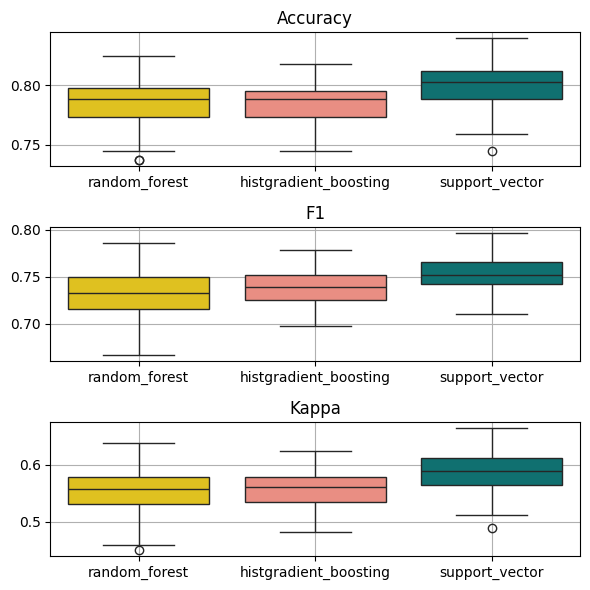

In [30]:
# 4.9 Plot confidence intervals for metrics
fig, ax = plt.subplots(3,1, figsize=(6,6))
axs = ax.flatten()
sns.boxplot(
    pd.DataFrame(bootstrap_model_ci).T['accuracy'].to_dict(), 
    palette=['gold','salmon','teal'], ax=axs[0]
)
axs[0].set_title('Accuracy')
axs[0].grid(True)
sns.boxplot(
    pd.DataFrame(bootstrap_model_ci).T['f1'].to_dict(), 
    palette=['gold','salmon','teal'], ax=axs[1]
)
axs[1].set_title('F1')
axs[1].grid(True)
sns.boxplot(
    pd.DataFrame(bootstrap_model_ci).T['kappa'].to_dict(), 
    palette=['gold','salmon','teal'], ax=axs[2]
)
axs[2].set_title('Kappa')
axs[2].grid(True)
plt.tight_layout()
plt.show()


Accuracy: 0.876
F1 Score: 0.844
ROC AUC score: 0.956
Precision: 0.831
Recall: 0.857
              precision    recall  f1-score   support

          CH       0.91      0.89      0.90        98
          MM       0.83      0.86      0.84        63

    accuracy                           0.88       161
   macro avg       0.87      0.87      0.87       161
weighted avg       0.88      0.88      0.88       161



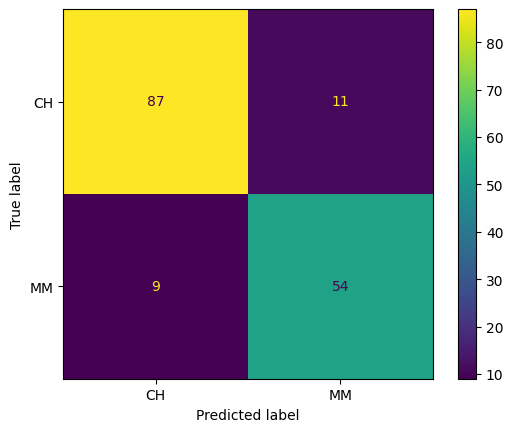

In [ ]:
# 4.10 Predict on test data and get accuracy and confusion matrix
y_hat = results['histgradient_boosting'].predict(X_test)
y_hat_score = results['histgradient_boosting'].predict_proba(X_test)[:,1]
print(f'Accuracy: {accuracy_score(y_test_enc, y_hat):.3f}')
print(f'F1 Score: {f1_score(y_test_enc, y_hat):.3f}')
print(f'ROC AUC score: {roc_auc_score(y_test_enc, y_hat_score):.3f}')
print(f'Precision: {precision_score(y_test_enc, y_hat, pos_label=1):.3f}')
print(f'Recall: {recall_score(y_test_enc, y_hat, pos_label=1):.3f}')
print(classification_report(y_test_enc, y_hat, target_names=label_encoder.classes_))
ConfusionMatrixDisplay.from_predictions(y_test_enc, y_hat, display_labels=label_encoder.classes_)
plt.show()

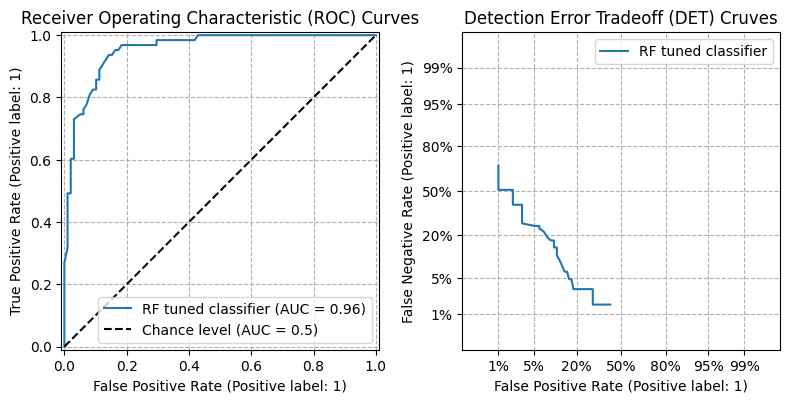

In [ ]:
# 4.11 Visualize the probabilities of scores of the classifier
fig, [ax_roc, ax_det] = plt.subplots(1,2, figsize=(8,8))
RocCurveDisplay.from_predictions(
    y_test_enc, y_hat_score, ax=ax_roc, 
    plot_chance_level=True, name='RF tuned classifier'
)
DetCurveDisplay.from_predictions(
    y_test_enc, y_hat_score, ax=ax_det, 
    name='RF tuned classifier'
)
ax_roc.set_title("Receiver Operating Characteristic (ROC) Curves")
ax_det.set_title("Detection Error Tradeoff (DET) Cruves")
ax_roc.grid(linestyle='--')
ax_det.grid(linestyle='--')
ax_det.set_aspect('equal')
plt.legend()
plt.tight_layout()
plt.show()

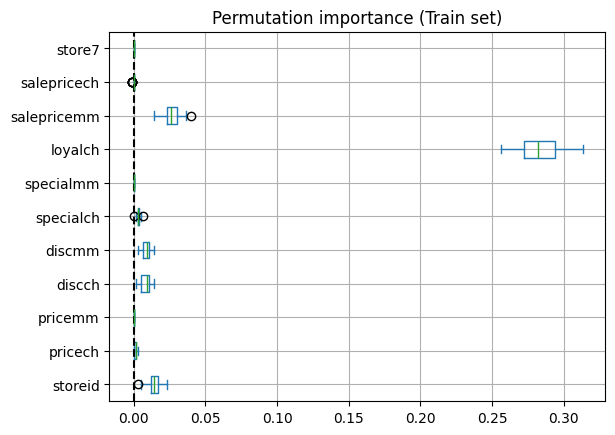

In [ ]:
# 4.12 Get the importance of variables
importance = permutation_importance(
    results['histgradient_boosting'].best_estimator_, 
    X_train, y_train_enc, 
    n_repeats=25, random_state=2024
)
importance_df = pd.DataFrame(importance.importances.T, columns=X_train.columns)
ax = importance_df.plot.box(vert=False)
ax.axvline(x=0, color='k', linestyle='--')
ax.set_title('Permutation importance (Train set)')
ax.grid(True)
plt.show()

### 5. Model saving
**Objective**: Save the model and some critical information we consider necessary

In [28]:
# Step 5. Save the model for further usage
# 5.1 Create model dictionary
model_dict = {
    'model': results['histgradient_boosting'].best_estimator_,
    'predictors': X_train.columns.to_list(),
    'target_name': y_train.name,
    'algorithm_name': 'Histogram Gradient Boosting',
    'metrics': 'Accuracy: 0.876, F1: 0.844'
}

In [29]:
# 5.2 Save the model dictionary
try:
    with open('../api/orange_juice_model_dict.pkl', 'wb') as file:
        pickle.dump(model_dict, file)
    logger.info("Save succesful")
except Exception as e:
    logger.error(f"An error occurred: {e}")

### 6. Notes
**Objective**: Add some comments or experiments done on experimenting

[1] Hothorn et al. The Design and Analysis of Benchmark Experiments. Zeileis.org. Retrieved on May 1th 2025. https://www.zeileis.org/papers/Hothorn+Leisch+Zeileis-2005.pdf  
[2] Eugster et al. Exploratory Analysis of Benchmark Experiments – An Interactive Approach. Retrieved on May 1th 2025. https://epub.ub.uni-muenchen.de/10604/1/tr56.pdf  
[3] Kuhn, Max. The Caret Package. March 27th 2019. https://topepo.github.io/caret/index.html  